In [52]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import random

#This first cell is loading the data into Jupyter, I already 
#downloaded the data into Onedrive, copied them into a personal folder and unzipped them. 
data_dir = r'path/to/your/data'  # Update this to point to your local dataset
print(os.listdir(data_dir))

['.DS_Store', 'epidural', 'multi', 'subdural', 'normal', 'subarachnoid', 'intraventricular', 'intraparenchymal']


In [53]:
#Path to the main dataset 
#Within these folders are subfolders for each hemorrhage type. 

#List the hemorrhage type (folders name in dataset)
classes = [
    "epidural",
    "intraparenchymal",
    "intraventricular",
    "multi",
    "normal",
    "subarachnoid",
    "subdural"
]
#image file paths (X data)
#each corresponding label ( y data)
image_paths = []
labels = []

#Loop through each hemorrhage type
for category in classes:
    #Construct the full path to the image folder
    #I selected the "brain_window" images for consistency
    # Note: dataset expected at data_dir/<hemorrhage_type>/brain_window/
    category_path = os.path.join(data_dir, category, "brain_window")
    #Check to see if the folder exists (may help reduce errors)
    if os.path.exists(category_path):
        for file in os.listdir(category_path): #loop through all files in brain_window folder
            if file.lower().endswith(".jpg"): #only selected image files .lower() ensures case matching
                #store full file path and type 
                image_paths.append(os.path.join(category_path, file))
                labels.append(category)
    else:
        print(f"Missing folder: {category_path}") #print a warning if the expected folder is missing 
#print total number of images loaded
print("Total images loaded:", len(image_paths))

#Checking dataset for balance which we will need 
#later on 
from collections import Counter
class_counts = Counter(labels)
print(class_counts)



Total images loaded: 114013
Counter({'subdural': 32200, 'multi': 32074, 'subarachnoid': 16423, 'intraparenchymal': 15664, 'intraventricular': 9878, 'normal': 6080, 'epidural': 1694})


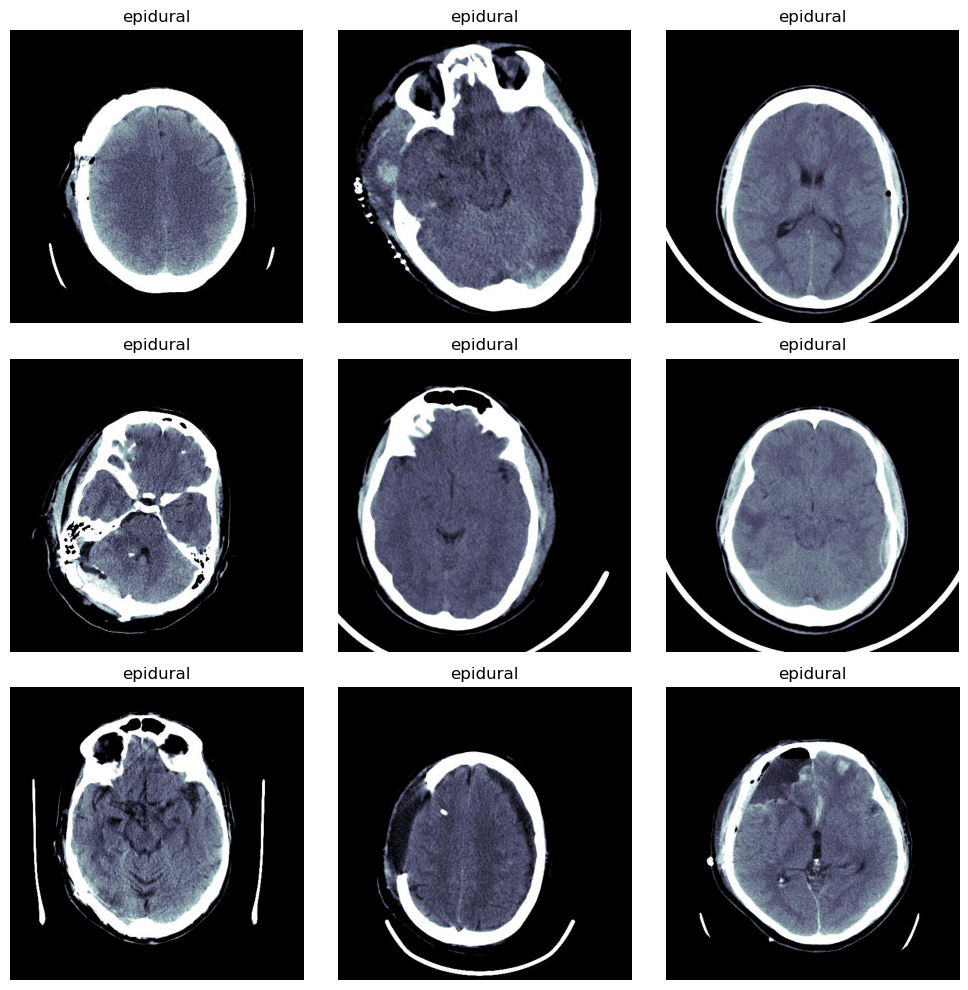

In [54]:
import matplotlib.pyplot as plt
from PIL import Image
#Create a figure to display images
plt.figure(figsize=(10, 10))
#Loop through first 9 images of the dataset to create 
#a 3x3 grid of the scans
for i in range(9):
    img = Image.open(image_paths[i]) #open file image location
    plt.subplot(3, 3, i + 1) #define the plotting position on the subplot
    plt.imshow(img, cmap="gray") #display image in greyscale
    plt.title(labels[i])
    plt.axis("off")
#spacing between the subplots to prevent overlapping images
plt.tight_layout()
plt.show()

In [55]:
import numpy as np
from PIL import Image
import random
from collections import Counter


sample_size = 500 #need something manageable for practice so randomly choose
#a smaller subset of images. 

#The random sample choose <sample_size> index positions from the full dataset. 
#the range(len(image_paths)): possible positions are 0,1,2,3,... up to total_images-1
indices = random.sample(range(len(image_paths)), sample_size)

#use the indices to select image paths and type labels 
sample_image_paths = [image_paths[i] for i in indices]
sample_labels = [labels[i] for i in indices]

#Now create someplace to store the processed data
#Lists that will store our image data and labels
X = []   #will store the image arrays
y = []   #will store the corresponding labels

#Resize all images so they have the same dimensions. Took these dimensions from most of our class/lab data
target_size = (128, 128)

#Loop through every selected image path and its label
#The command zip(sample_image_paths, sample_labels) pairs each image path with its label
#enumerate(...) adds a counter i = 0, 1, 2, 3, ...

for i, (path, label) in enumerate(zip(sample_image_paths, sample_labels)):
      #Progress update every 200 images to ensure the code is running
    #was taking so long, I needed to know if it was working
    if i % 200 == 0:
        print("Processing image:", i) #this was a progress update 
    
    #Open the image file
    img = Image.open(path)
    
    #Convert the image to grayscale
    #Data was originally grayscale, so keep it that way
    img = img.convert("L")
    
    #Resize the image so all inputs are the same size
    #This ensures the CNN receives a consistent input shape
    img = img.resize(target_size)
    
    #Convert the image into a NumPy array
    #Each pixel becomes a numerical value (0–255)
    img_array = np.array(img)
    
    #Add the processed image array to our dataset
    X.append(img_array)
    
    #Store the corresponding label (hemorrhage type)
    y.append(label)

#Convert lists into NumPy arrays 
X = np.array(X)
y = np.array(y)

#Print dataset shape to verify everything loaded correctly
print("X shape:", X.shape)
print("y shape:", y.shape)


#Normalize pixel values from [0,255] to [0,1]
#This improves neural network training stability
X = X / 255.0
print("Final X shape:", X.shape)


#Add the channel dimension required for CNN input
# Current shape: (12000, 128, 128)
# New shape:    (12000, 128, 128, 1)
#3D shape

#X has shape (2000,128,128). After reviewing code for CNN
#it shows that CNN expect an input of (number of images, height, width, channels (color))
#since greyscale, the number of channels is 1
#Also, the -1 tells numpy to figure out the number of images automatically, 
#since I already have 2000 images the new shape is:
#2000,128,128,1
X = X.reshape(-1, 128, 128, 1)
print("Updated X shape:", X.shape)

#Beginning stages of classification
#Create binary labels:
#0 = normal
#1 = hemorrhage present
y_binary = []

for label in y:
    if label == "normal":
        y_binary.append(0)
    else:
        y_binary.append(1)
#Convert binary labels into a numpy array
y_binary = np.array(y_binary)

#Check to see how many examples are in each binary class
print("Binary label counts:", Counter(y_binary))

Processing image: 0
Processing image: 200
Processing image: 400
X shape: (500, 128, 128)
y shape: (500,)
Final X shape: (500, 128, 128)
Updated X shape: (500, 128, 128, 1)
Binary label counts: Counter({np.int64(1): 472, np.int64(0): 28})


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

#Split the dataset into training and testing sets
#Just selected size, and random state according to previous assignments 
#training set: model will learn from this
#testing set: used later to evaluate model performance on new data

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, #input images
    y_binary, #binary labels
    test_size=0.2, #20% of data goes into the test set
    random_state=42, #reproducibility (from previous labs just added in)
    stratify=y_binary #keeps same class proportion in train and testing sets because our
    #data is very imbalanced. I was looking for ways to handle the imbalance... lets see how this works, I have
    #not used this command before. 
)
#Print the shapes to confirm the split worked
print("X_train_bin shape:", X_train_bin.shape)
print("X_test_bin shape:", X_test_bin.shape)
print("y_train_bin shape:", y_train_bin.shape)
print("y_test_bin shape:", y_test_bin.shape)

#Flatten images for logistic regression into a 1D vector since logistic regression
#cannot do 2D or 3D image
#we are going 128,128,1 to 128,128 = 16384 features (every scan becomes a vector of 16384 length)\
"""
The following lines keeps the number of entries the same but flattens the internal structure of each image
independently so that it's just a vector So X_train_bin.shape[0]=400 if total sample size = 500 and we have 0.2
as test train split parameter, so then it reshapes our previously 400x128x128x1 4D matrix into a 400*16384 2D matrix.
"""
X_train_flat = X_train_bin.reshape(X_train_bin.shape[0], -1) #-1 means collapse it all into one long vector
X_test_flat = X_test_bin.reshape(X_test_bin.shape[0], -1)
print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape:", X_test_flat.shape)

#Initialize model
#For the binary, logistic regression will estimate the probability that an image 
#belongs to hemorrhage or normal
log_reg = LogisticRegression(max_iter=1000)

#Train the model - learns from the flattened training images and their labels
#It is asking and answering "What pixel patterns make the hemorrhage more likely?"
log_reg.fit(X_train_flat, y_train_bin)

#Predict on test set - the model will predict 0 - normal or 1 - hemorrhage
y_pred_log = log_reg.predict(X_test_flat)

#Compute the classification accuracy - what fraction of test images were classified correctly 
print("Logistic Regression Accuracy:", accuracy_score(y_test_bin, y_pred_log))


X_train_bin shape: (400, 128, 128, 1)
X_test_bin shape: (100, 128, 128, 1)
y_train_bin shape: (400,)
y_test_bin shape: (100,)
X_train_flat shape: (400, 16384)
X_test_flat shape: (100, 16384)
Logistic Regression Accuracy: 0.94


In [57]:
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
#Multiclass Softmax - this is still logistic regression just now will we be using multiple classes. 
#Note is that I ended up removing the type "Multi" because I could not get this softmax to work with it

X_multi=[] #images that belong to a type/class
Y_multi_text=[] #the corresponding labels in string form

#Loop through every image stored in X and its corresponding label in Y
for i in range(len(y)):
    #If the label is NOT multi, we will keep the image
    #I ended up researching and figuring out that for softmax, it assumes each of the classes belongs to 
    #exactly one class so we do need to remove the multi class type.
    if y[i]!="multi":
        X_multi.append(X[i])
        Y_multi_text.append(y[i])

#Convert lists to numpy arrays
X_multi=np.array(X_multi)
Y_multi_text=np.array(Y_multi_text)
#Print the shapes to verify how many images remain
print("X_multi shape:", X_multi.shape)
print("y_multi_text shape:", Y_multi_text.shape)

#Print the number of examples in each class to check if the dataset is balanced.
print("Class counts:", Counter(Y_multi_text))


#Similar to logistic regression, we need to convert the types into numbers

class_map = {
    "epidural": 0,
    "intraparenchymal": 1,
    "intraventricular": 2,
    "subarachnoid": 3,
    "subdural": 4,
    "normal": 5
}

#Convert each text label into a numeric label
# Example:
#   "epidural" -> 0
#   "normal"   -> 5
Y_multi = np.array([class_map[label] for label in Y_multi_text])


#Print the unique numeric labels to confirm that all 6 classes are present
print("Unique numeric labels:", np.unique(Y_multi))

#Print the first few numeric labels 
print("First 10 numeric labels:", Y_multi[:10])

#Next we will split the data into test/training set mirrored like what I did in the logistic section
X_train_multi, X_test_multi, Y_train_multi, Y_test_multi = train_test_split(
    X_multi,          #the multiclass image data
    Y_multi,          #the corresponding numeric class labels
    test_size=0.2,    #20% for test set, 80% for training set
    random_state=42,  #reproducibility 
    stratify=Y_multi  #keep class proportions similar in both sets
)

#Print shapes to verify the split
print("X_train_multi shape:", X_train_multi.shape)
print("X_test_multi shape:", X_test_multi.shape)
print("y_train_multi shape:", Y_train_multi.shape)
print("y_test_multi shape:", Y_test_multi.shape)

#Flattening the images so each image becomes a vector length of 16384
X_train_multi_flat = X_train_multi.reshape(X_train_multi.shape[0], -1)
X_test_multi_flat = X_test_multi.reshape(X_test_multi.shape[0], -1)

#Print the shapes to confirm flattened 
print("X_train_multi_flat shape:", X_train_multi_flat.shape)
print("X_test_multi_flat shape:", X_test_multi_flat.shape)

#Now we will initialize the multi class softmax regression

softmax_model = LogisticRegression(
    max_iter=2000,

    solver="saga" # We also use solver="saga" because our dataset has many features (16384 pixels per image),
    #and saga the choice for high-dimensional problems. I also looked this up and have not used before
)
#train the model on the training data (image pixels --> class probabilities)
print("Starting Softmax Training")
softmax_model.fit(X_train_multi_flat,Y_train_multi)
print("Softmax training complete")
#After training we want to see how our model performs on test data
Y_predict_model=softmax_model.predict(X_test_multi_flat)
#Evaluate the model
print("Softmax Logistic Regression Accuracy:", accuracy_score(Y_test_multi,Y_predict_model))
#check to see what the model is actually predicting
print(np.unique(Y_predict_model))

X_multi shape: (352, 128, 128, 1)
y_multi_text shape: (352,)
Class counts: Counter({np.str_('subdural'): 152, np.str_('subarachnoid'): 80, np.str_('intraparenchymal'): 50, np.str_('intraventricular'): 37, np.str_('normal'): 28, np.str_('epidural'): 5})
Unique numeric labels: [0 1 2 3 4 5]
First 10 numeric labels: [3 4 4 2 2 3 4 4 4 1]
X_train_multi shape: (281, 128, 128, 1)
X_test_multi shape: (71, 128, 128, 1)
y_train_multi shape: (281,)
y_test_multi shape: (71,)
X_train_multi_flat shape: (281, 16384)
X_test_multi_flat shape: (71, 16384)
Starting Softmax Training
Softmax training complete
Softmax Logistic Regression Accuracy: 0.36619718309859156
[1 2 3 4 5]


In [63]:
#Using all of the data so that I can train a CNN more effectively
#Recycled some code from earlier in this document
import numpy as np
from PIL import Image
import random
from collections import Counter

#Now create someplace to store the processed data
#Lists that will store our image data and labels
Xfull = []   #will store the image arrays
yfull = []   #will store the corresponding labels

#Resize all images so they have the same dimensions. Took these dimensions from most of our class/lab data
target_size = (128, 128)

#Loop through every selected image path and its label
#The command zip(sample_image_paths, sample_labels) pairs each image path with its label
#enumerate(...) adds a counter i = 0, 1, 2, 3, ...

for i, (path, label) in enumerate(zip(image_paths, labels)):
      #Progress update every 200 images to ensure the code is running
    #was taking so long, I needed to know if it was working
    if i % 10000 == 0:
        print("Processing image:", i) #this was a progress update 
    
    #Open the image file
    img = Image.open(path)

    """Typically JPEG images are stored as RBG, even if they are grayscale, which would mean
       all 3 numbers having the same quantity, so (120, 120, 120), or (3, 3, 3). img.convert("L")
       just makes these three numbers into 1 number.
    """
    #Convert the image to grayscale
    #Data was originally grayscale, so keep it that way
    img = img.convert("L")

    """
    Extra Note: NumPy only adds a dimension to an array if it has multiple values per pixel, so since
    we are reducing from 3 entries to 1 entry, NumPy just drops the pixel intensity value entirely, so
    we get a matrix of the form (H, W).
    """
    
    #Resize the image so all inputs are the same size
    #This ensures the CNN receives a consistent input shape
    img = img.resize(target_size)
    
    #Convert the image into a NumPy array
    #Each pixel becomes a numerical value (0–255)
    img_array = np.array(img)
    
    #Add the processed image array to our dataset
    Xfull.append(img_array)
    
    #Store the corresponding label (hemorrhage type)
    yfull.append(label)

#Convert lists into NumPy arrays 
Xfull = np.array(Xfull)
yfull = np.array(yfull)

#Print dataset shape to verify everything loaded correctly
print("X shape:", Xfull.shape)
print("y shape:", yfull.shape)


#Normalize pixel values from [0,255] to [0,1]
#This improves neural network training stability
Xfull = Xfull / 255.0
print("Final X shape:", Xfull.shape)


#Add the channel dimension required for CNN input
# Current shape: (12000, 128, 128)
# New shape:    (12000, 128, 128, 1)
#3D shape

#X has shape (2000,128,128). After reviewing code for CNN
#it shows that CNN expect an input of (number of images, height, width, channels (color))
#since greyscale, the number of channels is 1
#Also, the -1 tells numpy to figure out the number of images automatically, 
#since I already have 2000 images the new shape is:
#2000,128,128,1
Xfull = Xfull.reshape(-1, 128, 128, 1)
print("Updated X shape:", Xfull.shape)

#Beginning stages of classification
#Create binary labels:
#0 = normal
#1 = hemorrhage present
y_binary = []

for label in yfull:
    if label == "normal":
        y_binary.append(0)
    else:
        y_binary.append(1)
#Convert binary labels into a numpy array
y_binary = np.array(y_binary)

#Check to see how many examples are in each binary class
print("Binary label counts:", Counter(y_binary))

Processing image: 0
Processing image: 10000
Processing image: 20000
Processing image: 30000
Processing image: 40000
Processing image: 50000
Processing image: 60000
Processing image: 70000
Processing image: 80000
Processing image: 90000
Processing image: 100000
Processing image: 110000
X shape: (114013, 128, 128)
y shape: (114013,)
Final X shape: (114013, 128, 128)
Updated X shape: (114013, 128, 128, 1)
Binary label counts: Counter({np.int64(1): 107933, np.int64(0): 6080})


In [93]:
from tensorflow import random as rd
from tensorflow.keras.layers import Dense, Activation, Dropout, Flatten, MaxPooling2D, Conv2D, Input
from keras import layers, models, Sequential, Input
import numpy as np
bk.clear_session()
np.random.seed(42)
rd.set_seed(42)
model = Sequential()
model.add(Input(shape=(128,128,1)))
model.add(Conv2D(32, (5,5), padding='valid', activation='relu'))
model.add(MaxPooling2D((3,3)))
model.add(Conv2D(32, (4,4), padding='valid', activation='relu'))
model.add(MaxPooling2D((3,3)))

model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(units=7, activation='softmax')) #7 classes with multi
model.compile(loss = 'sparse_categorical_crossentropy',
              optimizer = 'rmsprop',
              metrics = ['accuracy'])

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 124, 124, 32)   │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 41, 41, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 38, 38, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       147,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,967 (644.40 KB)

 Trainable params: 164,967 (644.40 KB)

 Non-trainable params: 0 (0.00 B)

None


In [70]:
#Applying Nikki's code from earlier on all of the data to get train-test-split

import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split

#Print the number of examples in each class to check how balanced the dataset is.
print("Class counts:", Counter(yfull))


#Similar to logistic regression, we need to convert the types into numbers

class_map = {
    "epidural": 0,
    "intraparenchymal": 1,
    "intraventricular": 2,
    "subarachnoid": 3,
    "subdural": 4,
    "normal": 5,
    "multi": 6
}

#Convert each text label into a numeric label
# Example:
#   "epidural" -> 0
#   "normal"   -> 5
Yfull = np.array([class_map[label] for label in yfull])


#Print the unique numeric labels to confirm that all 6 classes are present
print("Unique numeric labels:", np.unique(Yfull))

#Print the first few numeric labels 
print("First 10 numeric labels:", Yfull[:10])

#Next we will split the data into test/training set mirrored like what I did in the logistic section
X_train_full, X_test_full, Y_train_full, Y_test_full = train_test_split(
    Xfull,          #the multiclass image data
    Yfull,          #the corresponding numeric class labels
    test_size=0.2,    #20% for test set, 80% for training set
    random_state=42,  #reproducibility 
    stratify=Yfull  #keep class proportions similar in both sets
)

#Print shapes to verify the split
print("X_train_multi shape:", X_train_full.shape)
print("X_test_multi shape:", X_test_full.shape)
print("y_train_multi shape:", Y_train_full.shape)
print("y_test_multi shape:", Y_test_full.shape)

Class counts: Counter({np.str_('subdural'): 32200, np.str_('multi'): 32074, np.str_('subarachnoid'): 16423, np.str_('intraparenchymal'): 15664, np.str_('intraventricular'): 9878, np.str_('normal'): 6080, np.str_('epidural'): 1694})
Unique numeric labels: [0 1 2 3 4 5 6]
First 10 numeric labels: [0 0 0 0 0 0 0 0 0 0]
X_train_multi shape: (91210, 128, 128, 1)
X_test_multi shape: (22803, 128, 128, 1)
y_train_multi shape: (91210,)
y_test_multi shape: (22803,)


In [95]:
#IMPLEMENTING CNN
epochs = 10
#Reshaping training and testing arrays to make them 2D instead of 1D because Keras is annoying
history = model.fit(X_train_full, 
                    Y_train_full, 
                    epochs=epochs, 
                    batch_size=128,
                    verbose=1,
                    validation_data=(X_test_full, Y_test_full))

Epoch 1/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 134s 189ms/step - accuracy: 0.4042 - loss: 1.5418 - val_accuracy: 0.4500 - val_loss: 1.4604
Epoch 2/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 131s 183ms/step - accuracy: 0.4505 - loss: 1.4332 - val_accuracy: 0.4694 - val_loss: 1.3998
Epoch 3/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 130s 182ms/step - accuracy: 0.4746 - loss: 1.3734 - val_accuracy: 0.4892 - val_loss: 1.3406
Epoch 4/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 131s 184ms/step - accuracy: 0.4932 - loss: 1.3280 - val_accuracy: 0.5007 - val_loss: 1.3015
Epoch 5/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 132s 185ms/step - accuracy: 0.5049 - loss: 1.2950 - val_accuracy: 0.5126 - val_loss: 1.2740
Epoch 6/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 130s 182ms/step - accuracy: 0.5182 - loss: 1.2614 - val_accuracy: 0.5234 - val_loss: 1.2393
Epoch 7/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 129s 181ms/step - accuracy: 0.5295 - loss: 1.2346 - val_accuracy: 0.5333 - val_loss: 1.2185
Epoch 8/10
713/713 ━━━━━━━━━━━━━━━━━━━━ 132s 185ms/step - accuracy: 0.5379 -

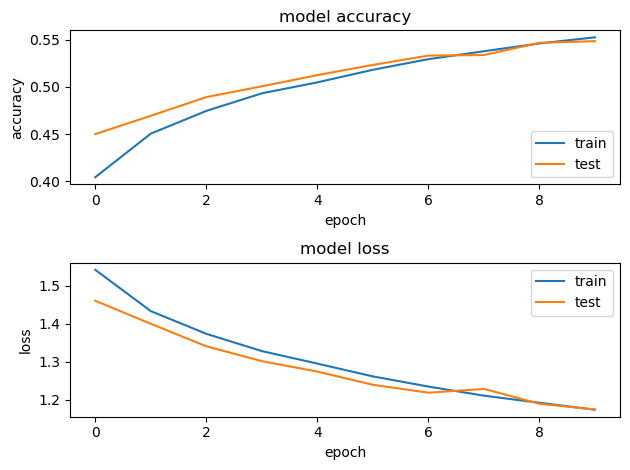

In [96]:
#saving the model and training progress
model.save("CNNmodel1.keras")
# plotting the metrics
fig = plt.figure()
plt.subplot(2,1,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='lower right')

plt.subplot(2,1,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')

plt.tight_layout()

#fig

In [100]:
#Training for two more epochs (testing whether loading model works)
modelreloaded = keras.models.load_model('CNNmodel1.keras')
history2 = modelreloaded.fit(X_train_full, 
                    Y_train_full, 
                    epochs=12, 
                    batch_size=128,
                    verbose=1,
                    validation_data=(X_test_full, Y_test_full),
                    initial_epoch=10)

Epoch 11/12
713/713 ━━━━━━━━━━━━━━━━━━━━ 137s 192ms/step - accuracy: 0.5577 - loss: 1.1613 - val_accuracy: 0.5538 - val_loss: 1.1701
Epoch 12/12
713/713 ━━━━━━━━━━━━━━━━━━━━ 130s 182ms/step - accuracy: 0.5629 - loss: 1.1468 - val_accuracy: 0.5619 - val_loss: 1.1488


In [101]:
#Training for three additional epochs. Since I'm still in the same python script, I don't need to reload
#the model -- I can continue from where I left off.
history3 = modelreloaded.fit(X_train_full,
                             Y_train_full,
                             epochs=15,
                             batch_size=128,
                             verbose=1,
                             validation_data=(X_test_full, Y_test_full),
                             initial_epoch=12)

Epoch 13/15
713/713 ━━━━━━━━━━━━━━━━━━━━ 132s 185ms/step - accuracy: 0.5663 - loss: 1.1388 - val_accuracy: 0.5603 - val_loss: 1.1536
Epoch 14/15
713/713 ━━━━━━━━━━━━━━━━━━━━ 132s 185ms/step - accuracy: 0.5731 - loss: 1.1266 - val_accuracy: 0.5638 - val_loss: 1.1578
Epoch 15/15
713/713 ━━━━━━━━━━━━━━━━━━━━ 131s 184ms/step - accuracy: 0.5742 - loss: 1.1195 - val_accuracy: 0.5630 - val_loss: 1.1521


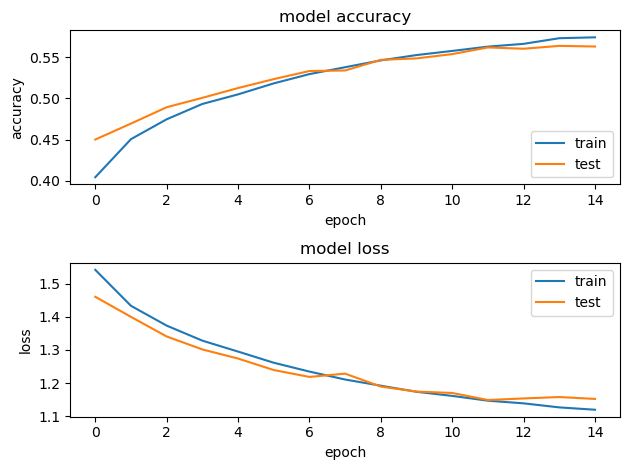

In [111]:
# Combining all 3 history variables so that I can plot them (code gotten from Gemini)
combined_history = {}

for key in history.history.keys():
    # Join the lists of values from both sessions
    combined_history[key] = history.history[key] + history2.history[key] + history3.history[key]

#Plotting total history -- we don't need a second .history because combined_history is just
#a dictionary object and not a keras.History object.
#saving the model and training progress
model.save("CNNmodel1.keras")
# plotting the metrics
fig = plt.figure()
plt.subplot(2,1,1)
plt.plot(combined_history['accuracy'])
plt.plot(combined_history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='lower right')

plt.subplot(2,1,2)
plt.plot(combined_history['loss'])
plt.plot(combined_history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')

plt.tight_layout()

#fig

In [112]:
#Saving our improved model so that we can access it later
modelreloaded.save("CNNImprovedModel.keras")